In [1]:
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.12.0'

## Data retrieval and collection

In [11]:
import pandas as pd
data=pd.read_csv("binary_classification_moons.csv")
data.head(6)  #check if dataset is loaded

,X1,X2,label
0,-0.009332,0.390981,1
1,0.954574,-0.473756,1
2,0.918526,-0.425196,1
3,0.412768,-0.376385,1
4,-0.845320,0.528799,0
5,0.579542,-0.352979,1


# Data Cleaning


In [12]:
data.describe()


,X1,X2,label
count,1000.000000,1000.000000,1000.00000
mean,0.499552,0.249196,0.50000
std,0.867371,0.494822,0.50025
min,-1.061751,-0.571697,0.00000
25%,-0.019860,-0.216408,0.00000
50%,0.502008,0.248686,0.50000
75%,1.020851,0.694288,1.00000
max,2.064637,1.042677,1.00000


Here, the data is clean, so no additional preprocessing steps are required.



### Feature Design

In NN, feature desisn is an automatic step. 

### Algorithm Selection

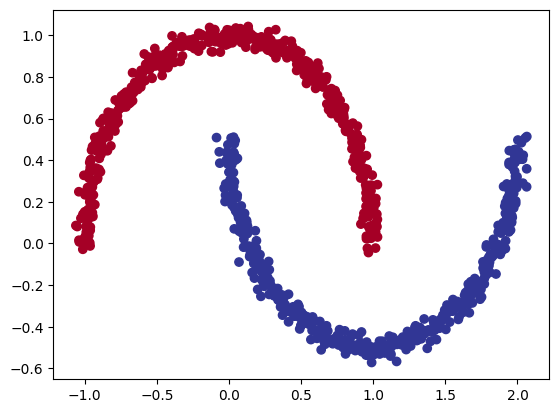

In [13]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(
            x=data.X1, 
            y=data.X2, 
            c=data.label, 
            cmap=plt.cm.RdYlBu
            );

In [14]:
# vectorizing X1 and X2 into a single tensor/nparray

X = data[['X1', 'X2']].values
y = data['label'].values

In [15]:
print(f"First 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")

First 5 X features:
[[-0.00933187  0.39098105]
 [ 0.95457387 -0.47375583]
 [ 0.9185256  -0.42519648]
 [ 0.41276802 -0.37638459]
 [-0.84532016  0.52879908]]

First 5 y labels:
[1 1 1 1 0]


In [16]:
# Check the shapes of our features and labels
X.shape, y.shape

((1000, 2), (1000,))

In [17]:
# Turn data into tensors
# Otherwise this causes issues with computations later on
import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# View the first five samples
X[:5], y[:5]

/var/folders/gv/7b4xm2w16mj78klz1hpwcnn80000gn/T/ipykernel_74065/3536051194.py:5: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  y = torch.from_numpy(y).type(torch.float)


(tensor([[-0.0093,  0.3910],
         [ 0.9546, -0.4738],
         [ 0.9185, -0.4252],
         [ 0.4128, -0.3764],
         [-0.8453,  0.5288]]),
 tensor([1., 1., 1., 1., 0.]))

In [19]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [20]:
# Standard PyTorch imports
import torch
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [21]:
# 1. Construct a model class that subclasses nn.Module
class ModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. Create 2 nn.Linear layers capable of handling X and y input and output shapes
        self.layer_1 = nn.Linear(in_features=2, out_features=5) # takes in 2 features (X), produces 5 features
        self.layer_2 = nn.Linear(in_features=5, out_features=1) # takes in 5 features, produces 1 feature (y)
    
    # 3. Define a forward method containing the forward pass computation
    def forward(self, x):
        # Return the output of layer_2, a single feature, the same shape as y
        return self.layer_2(self.layer_1(x)) # computation goes through layer_1 first then the output of layer_1 goes through layer_2

# 4. Create an instance of the model and send it to target device
model_0 = ModelV0().to(device)
model_0

ModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [22]:
model = model_0

In [23]:
# Make predictions with the model
untrained_preds = model(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[0.5548],
        [0.8191],
        [0.7455],
        [0.8106],
        [0.9960],
        [1.0540],
        [0.8103],
        [0.7847],
        [0.7032],
        [0.8045]], grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


### Loss Function Selection

In [24]:
# Create a loss function
# loss_fn = nn.BCELoss() # BCELoss = no sigmoid built-in
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

In [25]:
# View the frist 5 outputs of the forward pass on the test data
y_logits = model(X_test.to(device))[:5]
y_logits

tensor([[0.5548],
        [0.8191],
        [0.7455],
        [0.8106],
        [0.9960]], grad_fn=<SliceBackward0>)

In [26]:
# Use sigmoid on model logits
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.6352],
        [0.6940],
        [0.6782],
        [0.6922],
        [0.7303]], grad_fn=<SigmoidBackward0>)

In [27]:
# Find the predicted labels (round the prediction probabilities)
y_preds = torch.round(y_pred_probs)

# In full
y_pred_labels = torch.round(torch.sigmoid(model(X_test.to(device))[:5]))

# Check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([1., 1., 1., 1., 1.], grad_fn=<SqueezeBackward0>)

In [28]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

### Model Learning

In [29]:
torch.manual_seed(42)

# Set the number of epochs
epochs = 100

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device) 


### Model Evaluation

In [31]:
from utils import train_and_test_loop

train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

Epoch: 0 | Loss: 0.71534, Accuracy: 50.00% | Test loss: 0.71500, Test acc: 50.00%
Epoch: 10 | Loss: 0.62229, Accuracy: 67.50% | Test loss: 0.63058, Test acc: 66.00%
Epoch: 20 | Loss: 0.55749, Accuracy: 76.88% | Test loss: 0.57097, Test acc: 73.00%
Epoch: 30 | Loss: 0.50169, Accuracy: 76.88% | Test loss: 0.51967, Test acc: 74.50%
Epoch: 40 | Loss: 0.45447, Accuracy: 78.88% | Test loss: 0.47609, Test acc: 76.00%
Epoch: 50 | Loss: 0.41697, Accuracy: 79.00% | Test loss: 0.44096, Test acc: 77.00%
Epoch: 60 | Loss: 0.38840, Accuracy: 80.38% | Test loss: 0.41349, Test acc: 76.50%
Epoch: 70 | Loss: 0.36677, Accuracy: 81.12% | Test loss: 0.39196, Test acc: 77.50%
Epoch: 80 | Loss: 0.35009, Accuracy: 81.50% | Test loss: 0.37472, Test acc: 78.50%
Epoch: 90 | Loss: 0.33682, Accuracy: 82.25% | Test loss: 0.36048, Test acc: 80.50%


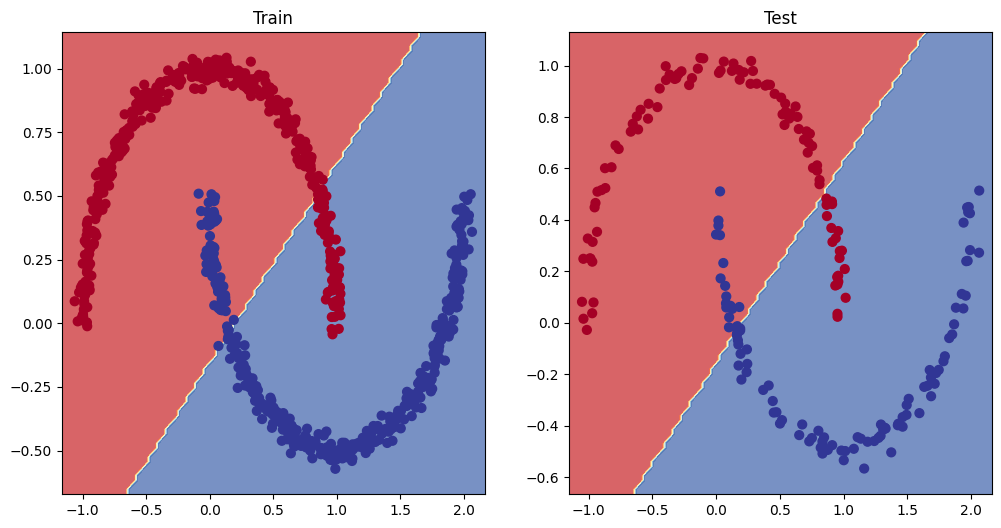

In [32]:
from utils import plot_decision_boundary

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

In machine learning terms, our model is `underfitting`, meaning it's not learning predictive patterns from the data.

Let's also plot the loss graph: 


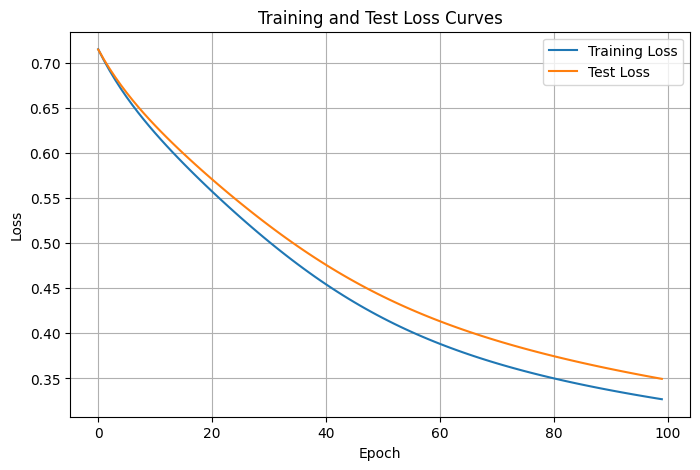

In [33]:

import matplotlib.pyplot as plt

def plot_loss_curves(train_losses, test_losses):
    """
    Plots training and testing loss curves.

    Args:
        train_losses (list): Loss values from training
        test_losses (list): Loss values from testing
    """
    epochs = range(len(train_losses))

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_losses, label="Training Loss")
    plt.plot(epochs, test_losses, label="Test Loss")
    
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Test Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss_curves(train_losses, test_losses)

## Improving an Underfitting Model

Let’s try to address our model’s **underfitting** problem.

Focusing specifically on the **model itself** (not the data), there are several common techniques we can use to increase its capacity to learn more complex patterns.

### Model Improvement Techniques

| Model improvement technique* | What does it do? |
| ----- | ----- |
| **Add more layers** | Each additional layer can increase the model’s ability to learn hierarchical and more complex patterns. Models with more layers are often described as being *deeper*. |
| **Add more hidden units** | Increasing the number of hidden units in a layer can improve the model’s representational power. Models with more units per layer are often described as being *wider*. |
| **Train for longer (more epochs)** | Giving the model more passes over the training data can allow it to learn patterns it may not have captured initially. |

The rest of the methods will be discussed in the next .ipynb file. 

> **Note:** Because these settings are chosen *before* training and tuned manually, they are referred to as **hyperparameters**.

---

### Improving the Model

To increase the model’s learning capacity, we’ll make the following changes:

- Add an extra hidden layer  
- Increase the number of hidden units from **5 → 10**  
- Train for longer, increasing epochs from **100 → 1000**

We’ll follow the same modeling steps as before, but with these updated hyperparameters, and then evaluate whether these changes help reduce underfitting and improve performance.


In [34]:
class ModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        
    def forward(self, x): # note: always make sure forward is spelt correctly!
        # Creating a model like this is the same as below, though below
        # generally benefits from speedups where possible.
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        # return z
        return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = ModelV1().to(device)
model_1

ModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [35]:
model = model_1
epochs = 1000

# Create a loss function
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

Epoch: 0 | Loss: 0.71976, Accuracy: 30.75% | Test loss: 0.70134, Test acc: 45.50%
Epoch: 10 | Loss: 0.58674, Accuracy: 79.62% | Test loss: 0.58552, Test acc: 78.00%
Epoch: 20 | Loss: 0.47594, Accuracy: 79.62% | Test loss: 0.48700, Test acc: 77.00%
Epoch: 30 | Loss: 0.39832, Accuracy: 81.00% | Test loss: 0.41841, Test acc: 77.00%
Epoch: 40 | Loss: 0.35499, Accuracy: 81.62% | Test loss: 0.37773, Test acc: 78.00%
Epoch: 50 | Loss: 0.32886, Accuracy: 82.62% | Test loss: 0.35055, Test acc: 80.50%
Epoch: 60 | Loss: 0.31010, Accuracy: 83.75% | Test loss: 0.32940, Test acc: 82.00%
Epoch: 70 | Loss: 0.29513, Accuracy: 84.75% | Test loss: 0.31171, Test acc: 83.50%
Epoch: 80 | Loss: 0.28276, Accuracy: 85.00% | Test loss: 0.29670, Test acc: 85.50%
Epoch: 90 | Loss: 0.27260, Accuracy: 85.62% | Test loss: 0.28413, Test acc: 86.50%
Epoch: 100 | Loss: 0.26443, Accuracy: 86.25% | Test loss: 0.27384, Test acc: 87.50%
Epoch: 110 | Loss: 0.25803, Accuracy: 87.00% | Test loss: 0.26561, Test acc: 87.50%
Epo

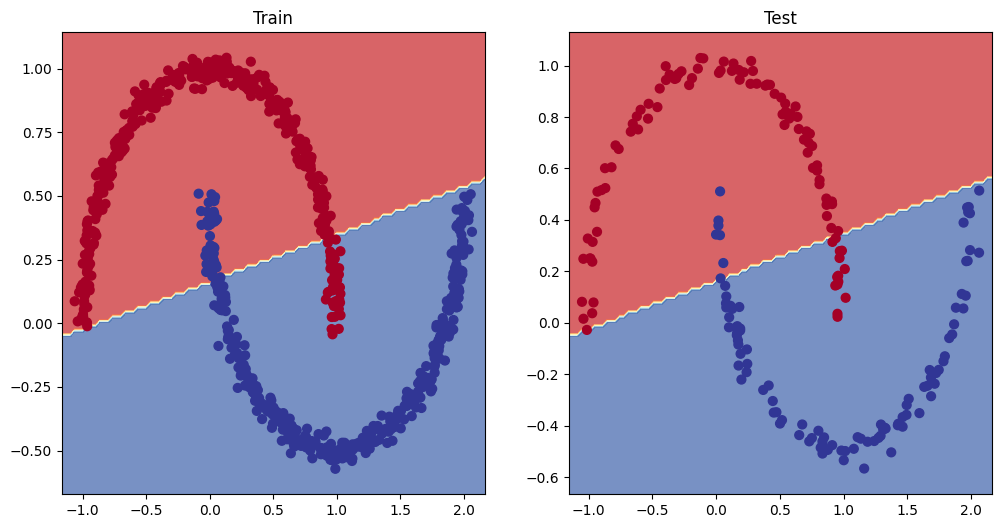

In [36]:
train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

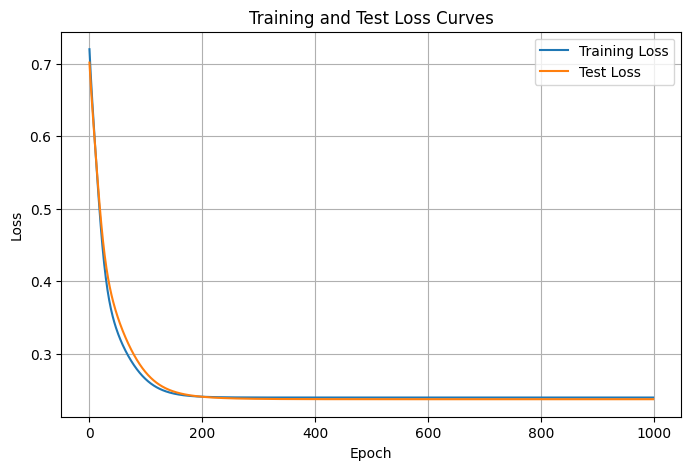

In [37]:
plot_loss_curves(train_losses, test_losses)

# Improving the model

In [57]:
class ModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=7)
        self.layer_4 = nn.Linear(in_features=7, out_features=6)
        self.layer_5 = nn.Linear(in_features=6, out_features=1)
        
        
        
    def forward(self, x): # note: always make sure forward is spelt correctly!
        # Creating a model like this is the same as below, though below
        # generally benefits from speedups where possible.
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        # return z
        return self.layer_5(self.layer_4(self.layer_3(self.layer_2(self.layer_1(x)))))

model_1 = ModelV1().to(device)
model_1

ModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=7, bias=True)
  (layer_4): Linear(in_features=7, out_features=6, bias=True)
  (layer_5): Linear(in_features=6, out_features=1, bias=True)
)

In [58]:
model = model_1
epochs = 2000

# Create a loss function
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

Epoch: 0 | Loss: 0.68849, Accuracy: 50.00% | Test loss: 0.68744, Test acc: 50.00%
Epoch: 10 | Loss: 0.68196, Accuracy: 70.25% | Test loss: 0.68123, Test acc: 74.00%
Epoch: 20 | Loss: 0.67319, Accuracy: 87.75% | Test loss: 0.67272, Test acc: 88.50%
Epoch: 30 | Loss: 0.65876, Accuracy: 86.50% | Test loss: 0.65852, Test acc: 85.50%
Epoch: 40 | Loss: 0.63090, Accuracy: 85.25% | Test loss: 0.63082, Test acc: 81.50%
Epoch: 50 | Loss: 0.56991, Accuracy: 83.25% | Test loss: 0.56996, Test acc: 79.00%
Epoch: 60 | Loss: 0.45055, Accuracy: 82.00% | Test loss: 0.45618, Test acc: 79.00%
Epoch: 70 | Loss: 0.34716, Accuracy: 82.62% | Test loss: 0.36468, Test acc: 80.50%
Epoch: 80 | Loss: 0.30568, Accuracy: 84.25% | Test loss: 0.32253, Test acc: 82.50%
Epoch: 90 | Loss: 0.28268, Accuracy: 85.00% | Test loss: 0.29510, Test acc: 84.50%
Epoch: 100 | Loss: 0.26617, Accuracy: 86.00% | Test loss: 0.27453, Test acc: 86.50%
Epoch: 110 | Loss: 0.25468, Accuracy: 87.25% | Test loss: 0.25989, Test acc: 88.00%
Epo

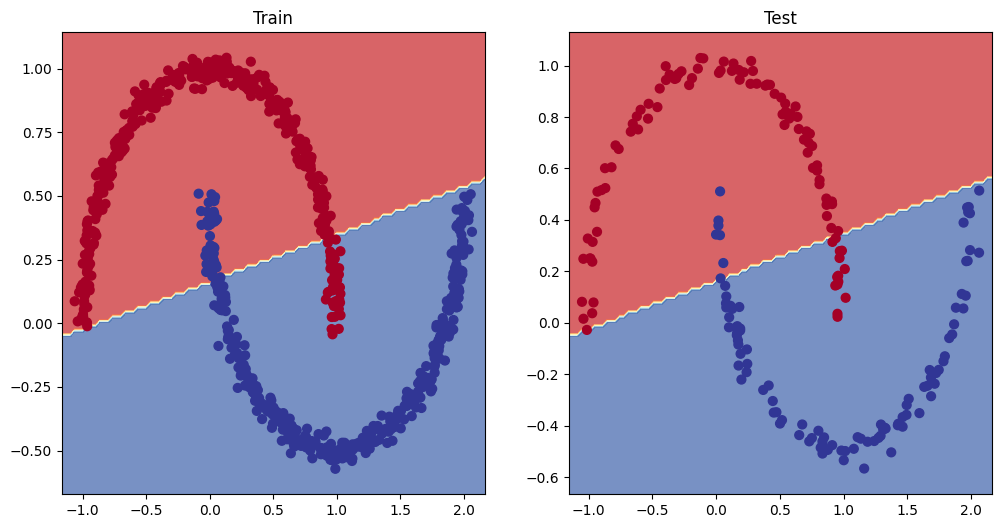

In [59]:
train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

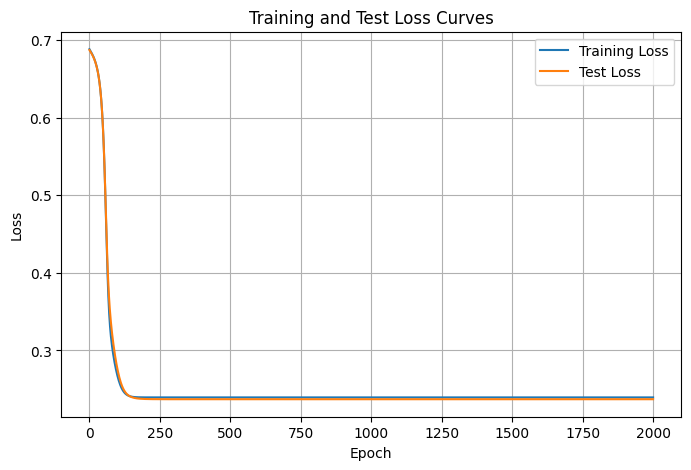

In [60]:
plot_loss_curves(train_losses, test_losses)

## TASK 3


In [70]:
class ModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # <- add in ReLU activation function
        # Can also put sigmoid in the model 
        # This would mean you don't need to use it on the predictions
        # self.sigmoid = nn.Sigmoid()

    def forward(self, x):
      # Intersperse the ReLU activation function between layers
       return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
    
model_2 = ModelV2().to(device)
model_2

ModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [71]:
model = model_2
epochs = 2000

# Create a loss function
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

Epoch: 0 | Loss: 0.70458, Accuracy: 50.00% | Test loss: 0.70307, Test acc: 50.00%
Epoch: 10 | Loss: 0.69326, Accuracy: 50.00% | Test loss: 0.69291, Test acc: 50.00%
Epoch: 20 | Loss: 0.68661, Accuracy: 50.00% | Test loss: 0.68691, Test acc: 50.00%
Epoch: 30 | Loss: 0.68069, Accuracy: 50.00% | Test loss: 0.68135, Test acc: 50.00%
Epoch: 40 | Loss: 0.67407, Accuracy: 50.00% | Test loss: 0.67507, Test acc: 50.00%
Epoch: 50 | Loss: 0.66554, Accuracy: 67.62% | Test loss: 0.66695, Test acc: 66.50%
Epoch: 60 | Loss: 0.65371, Accuracy: 82.50% | Test loss: 0.65570, Test acc: 78.00%
Epoch: 70 | Loss: 0.63698, Accuracy: 85.62% | Test loss: 0.63979, Test acc: 82.50%
Epoch: 80 | Loss: 0.61318, Accuracy: 84.75% | Test loss: 0.61696, Test acc: 82.50%
Epoch: 90 | Loss: 0.57966, Accuracy: 84.00% | Test loss: 0.58464, Test acc: 83.50%
Epoch: 100 | Loss: 0.53513, Accuracy: 83.38% | Test loss: 0.54194, Test acc: 83.50%
Epoch: 110 | Loss: 0.48279, Accuracy: 83.25% | Test loss: 0.49180, Test acc: 84.00%
Epo

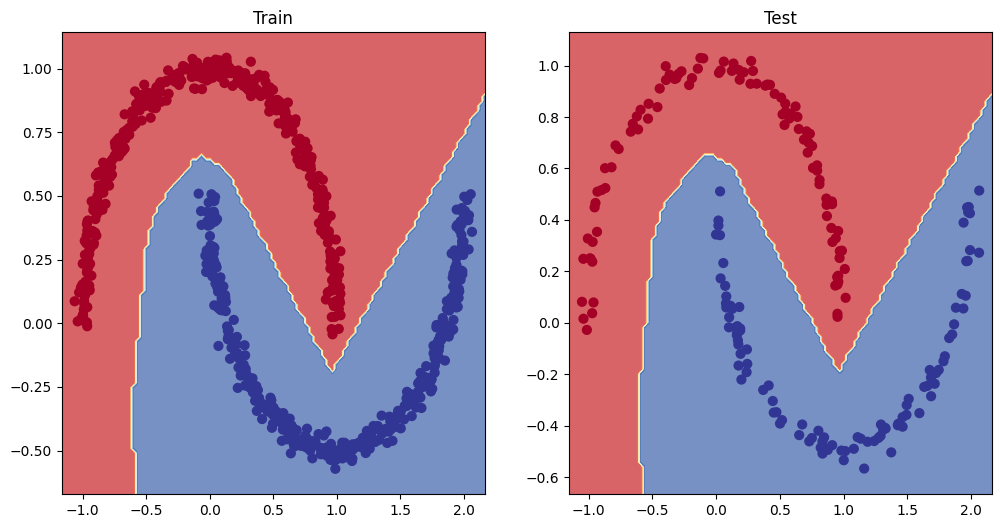

In [72]:
train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

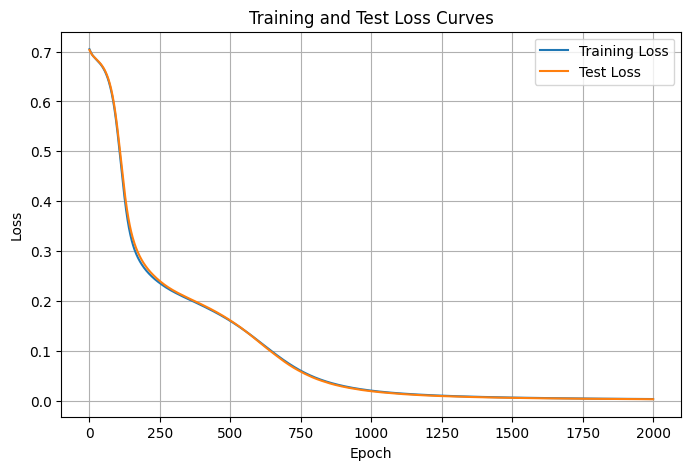

In [73]:
plot_loss_curves(train_losses, test_losses)

# Discussion 

## Task 2

For the task at hand, a neural network was constructed in order to classify data points within the moon shaped dataset. It is important to note that initially, the neural network had few linear layers and was underperforming. This was observed when looking at the decision boundary graph, which indicated that the model was underfitting the data since it was unable to understand the nonlinear relationship of the data. As such, new layers and neurons were added to the model and it was trained for more epochs.

## Task 3
The current task also made it possible to improve the classification model using the ReLU activation function between the hidden layers. In comparison with a linear network, the implementation of the non-linear activation function helped the model understand more complex decision boundaries. More epochs helped to achieve lower losses and higher accuracy in classification. The representation of the decision boundary illustrated a clearer distinction between the two classes than the previous tasks. The model managed to capture the non-linear relationships within the dataset.

# Conclusion

## Task 2
Underfitting was evident in the initial model because of its low complexity. The model's performance in classification improved when there were more layers, neurons, and epochs used for training. In this project, it is clear that the design of the model is essential in solving nonlinear classification problems.

## Task 3
The addition of ReLU as an activation function greatly enhanced the model’s capability to capture nonlinear interactions in the input data. The model performed better and generated more accurate decision boundaries compared to the previous models. This assignment illustrated the significance of activation functions in deep learning, where nonlinearity is a vital component for successful modeling.